In [1]:
# DAY 20 - MODEL EVALUATION

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Create fraud detection dataset

data = {
    "Transaction_Amount": [
        120, 250, 80, 5000, 150, 75, 3000, 200, 450, 7000,
        90, 180, 2500, 130, 6000
    ],

    "Transaction_Frequency": [
        2, 3, 1, 15, 2, 1, 12, 3, 4, 20,
        1, 2, 10, 2, 18
    ],

    "Account_Age_Days": [
        800, 600, 1000, 30, 700, 900, 45, 500, 400, 20,
        1200, 750, 60, 650, 25
    ],

    "International_Transaction": [
        0, 0, 0, 1, 0, 0, 1, 0, 0, 1,
        0, 0, 1, 0, 1
    ],

    "Fraud": [
        0, 0, 0, 1, 0, 0, 1, 0, 0, 1,
        0, 0, 1, 0, 1
    ]
}

fraud_data = pd.DataFrame(data)

print("Dataset created successfully!")
print(fraud_data)

Dataset created successfully!
    Transaction_Amount  Transaction_Frequency  Account_Age_Days  \
0                  120                      2               800   
1                  250                      3               600   
2                   80                      1              1000   
3                 5000                     15                30   
4                  150                      2               700   
5                   75                      1               900   
6                 3000                     12                45   
7                  200                      3               500   
8                  450                      4               400   
9                 7000                     20                20   
10                  90                      1              1200   
11                 180                      2               750   
12                2500                     10                60   
13                 130          

In [3]:
# Check the dataset

print("Dataset shape:")
print(fraud_data.shape)

print("\nMissing values:")
print(fraud_data.isnull().sum())

print("\nFraud distribution:")
print(fraud_data["Fraud"].value_counts())

Dataset shape:
(15, 5)

Missing values:
Transaction_Amount           0
Transaction_Frequency        0
Account_Age_Days             0
International_Transaction    0
Fraud                        0
dtype: int64

Fraud distribution:
Fraud
0    10
1     5
Name: count, dtype: int64


In [4]:
# Separate features and target

X = fraud_data[
    [
        "Transaction_Amount",
        "Transaction_Frequency",
        "Account_Age_Days",
        "International_Transaction"
    ]
]

y = fraud_data["Fraud"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (15, 4)
Target shape: (15,)


In [5]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (12, 4)
Testing data: (3, 4)


In [6]:
# Train Logistic Regression

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [7]:
# Train Decision Tree

decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=3
)

decision_tree.fit(X_train, y_train)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [8]:
# Train Random Forest

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=3
)

random_forest.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [9]:
# Train XGBoost

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [10]:
# Make predictions using all four models

logistic_pred = logistic_model.predict(X_test)
dt_pred = decision_tree.predict(X_test)
rf_pred = random_forest.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

print("Actual:", y_test.values)
print("Logistic Regression:", logistic_pred)
print("Decision Tree:", dt_pred)
print("Random Forest:", rf_pred)
print("XGBoost:", xgb_pred)

Actual: [0 1 0]
Logistic Regression: [0 1 0]
Decision Tree: [0 1 0]
Random Forest: [0 1 0]
XGBoost: [0 1 1]


In [11]:
# Calculate evaluation metrics for all models

models = {
    "Logistic Regression": (logistic_model, logistic_pred),
    "Decision Tree": (decision_tree, dt_pred),
    "Random Forest": (random_forest, rf_pred),
    "XGBoost": (xgb_model, xgb_pred)
}

metrics_results = []

for name, (model, predictions) in models.items():

    probabilities = model.predict_proba(X_test)[:, 1]

    metrics_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1 Score": f1_score(y_test, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, probabilities)
    })

metrics_df = pd.DataFrame(metrics_results)

print(metrics_df.round(3))

                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression     1.000        1.0     1.0     1.000     1.00
1        Decision Tree     1.000        1.0     1.0     1.000     1.00
2        Random Forest     1.000        1.0     1.0     1.000     1.00
3              XGBoost     0.667        0.5     1.0     0.667     0.75


In [12]:
# Save model evaluation results

metrics_df.to_csv(
    "classification_metrics_comparison.csv",
    index=False
)

print("Metrics comparison saved successfully!")
print(metrics_df.round(3))

Metrics comparison saved successfully!
                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression     1.000        1.0     1.0     1.000     1.00
1        Decision Tree     1.000        1.0     1.0     1.000     1.00
2        Random Forest     1.000        1.0     1.0     1.000     1.00
3              XGBoost     0.667        0.5     1.0     0.667     0.75


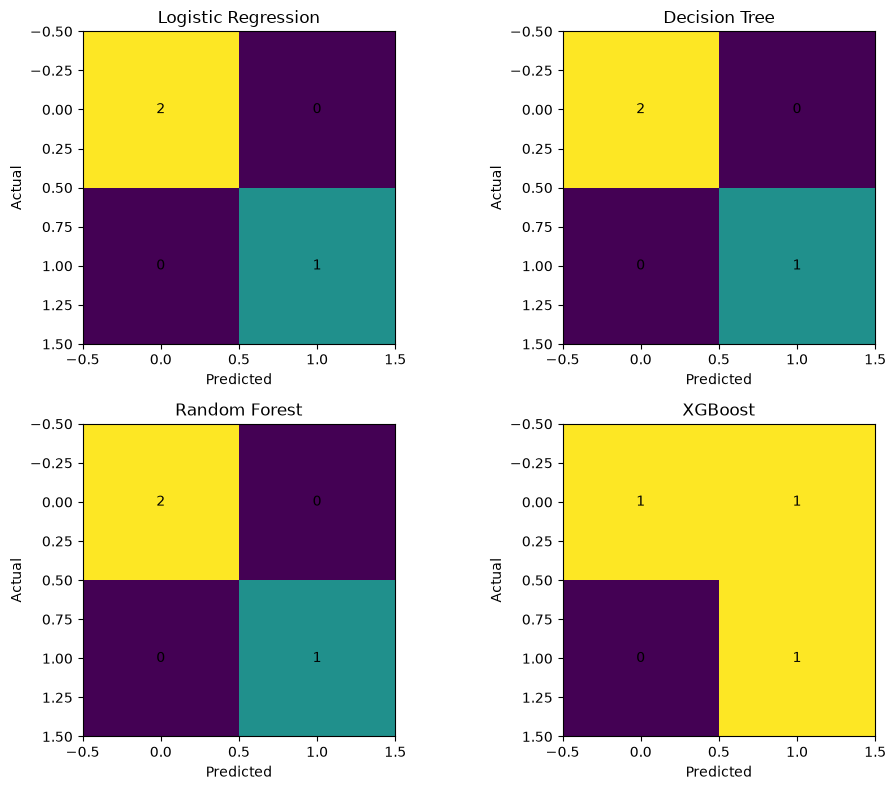

In [13]:
# Generate confusion matrices for all models

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, (name, (model, predictions)) in zip(axes.ravel(), models.items()):

    cm = confusion_matrix(y_test, predictions)

    ax.imshow(cm)

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, cm[i, j],
                ha="center",
                va="center"
            )

plt.tight_layout()

plt.savefig(
    "confusion_matrices.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
# Compare model strengths and weaknesses

print("Model Strengths and Weaknesses")

print("\nLogistic Regression:")
print("Strength: Simple and easy to interpret.")
print("Weakness: May struggle with complex patterns.")

print("\nDecision Tree:")
print("Strength: Easy to understand and explain.")
print("Weakness: Can overfit the training data.")

print("\nRandom Forest:")
print("Strength: More robust than a single decision tree.")
print("Weakness: Less easy to interpret.")

print("\nXGBoost:")
print("Strength: Powerful and can capture complex patterns.")
print("Weakness: Requires careful tuning and can overfit.")

Model Strengths and Weaknesses

Logistic Regression:
Strength: Simple and easy to interpret.
Weakness: May struggle with complex patterns.

Decision Tree:
Strength: Easy to understand and explain.
Weakness: Can overfit the training data.

Random Forest:
Strength: More robust than a single decision tree.
Weakness: Less easy to interpret.

XGBoost:
Strength: Powerful and can capture complex patterns.
Weakness: Requires careful tuning and can overfit.


In [15]:
# Why Accuracy Alone Can Mislead

print("Why Accuracy Alone Can Mislead")
print()
print("If 99% of transactions are genuine and 1% are fraud,")
print("a model predicting every transaction as genuine can get 99% accuracy.")
print("But it detects 0% of the fraud.")
print()
print("Recall is important when missing fraud is costly.")
print("Precision is important when false alarms are costly.")
print("F1 Score balances precision and recall.")
print("ROC-AUC measures how well the model separates the two classes.")

Why Accuracy Alone Can Mislead

If 99% of transactions are genuine and 1% are fraud,
a model predicting every transaction as genuine can get 99% accuracy.
But it detects 0% of the fraud.

Recall is important when missing fraud is costly.
Precision is important when false alarms are costly.
F1 Score balances precision and recall.
ROC-AUC measures how well the model separates the two classes.


In [16]:
# Day 20 Final Summary

print("Day 20 - Model Evaluation Complete")
print()
print("Evaluated 4 classification models:")
print("1. Logistic Regression")
print("2. Decision Tree")
print("3. Random Forest")
print("4. XGBoost")
print()
print("Calculated:")
print("- Accuracy")
print("- Precision")
print("- Recall")
print("- F1 Score")
print("- ROC-AUC")
print()
print("Generated confusion matrices.")
print("Compared model strengths and weaknesses.")
print("Learned why accuracy alone can be misleading.")
print()
print("Note: This evaluation uses a tiny synthetic dataset for demonstration.")

Day 20 - Model Evaluation Complete

Evaluated 4 classification models:
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. XGBoost

Calculated:
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

Generated confusion matrices.
Compared model strengths and weaknesses.
Learned why accuracy alone can be misleading.

Note: This evaluation uses a tiny synthetic dataset for demonstration.
